REFERENSI: https://developer.apple.com/documentation/Accelerate/compressing-an-image-using-linear-algebra

LINK COLLAB: https://colab.research.google.com/drive/16fyjIqhGplxVRzE5gAeSfgdK1DCeTBE6?usp=sharing


================ LOAD DATASET =================
Mengambil dataset wajah LFW...
Dataset berhasil dimuat!

Jumlah gambar : 13233
Ukuran gambar : (62, 47)

================ CONTOH GAMBAR =================
Index gambar : 10
Dimensi gambar : 62 x 47


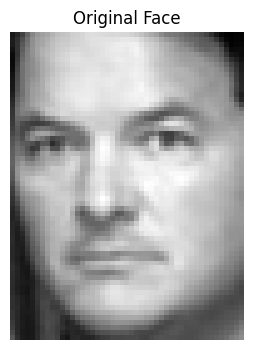


================ FLATTEN VECTOR =================
Shape matrix asli : (62, 47)
Shape vector : (2914,)

5 nilai awal vector:
[0.19215687 0.23006536 0.303268   0.4        0.4901961 ]

================ PENJELASAN SVD =================

A = U Σ VT

U     = basis fitur vertikal
Σ     = singular values / energi utama
VT    = basis fitur horizontal

SVD memecah gambar menjadi pola-pola utama.
Semakin besar singular value,
semakin penting fitur tersebut.


================ SVD PROCESS =================

Ukuran Matriks:
U     : (62, 47)
S     : (47,)
SIGMA : (47, 47)
VT    : (47, 47)

5 Singular Values Pertama:
[30.986488   3.3550367  2.238037   2.129474   1.0647008]


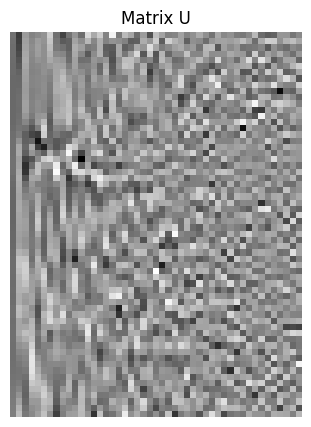

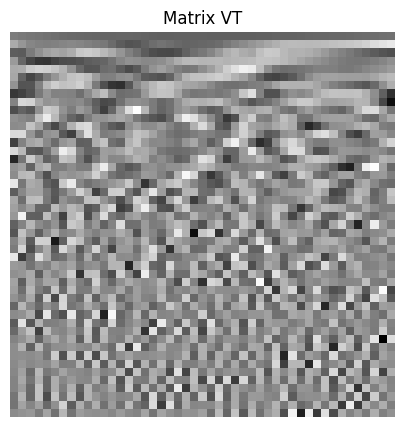


================ RECONSTRUCTION =================


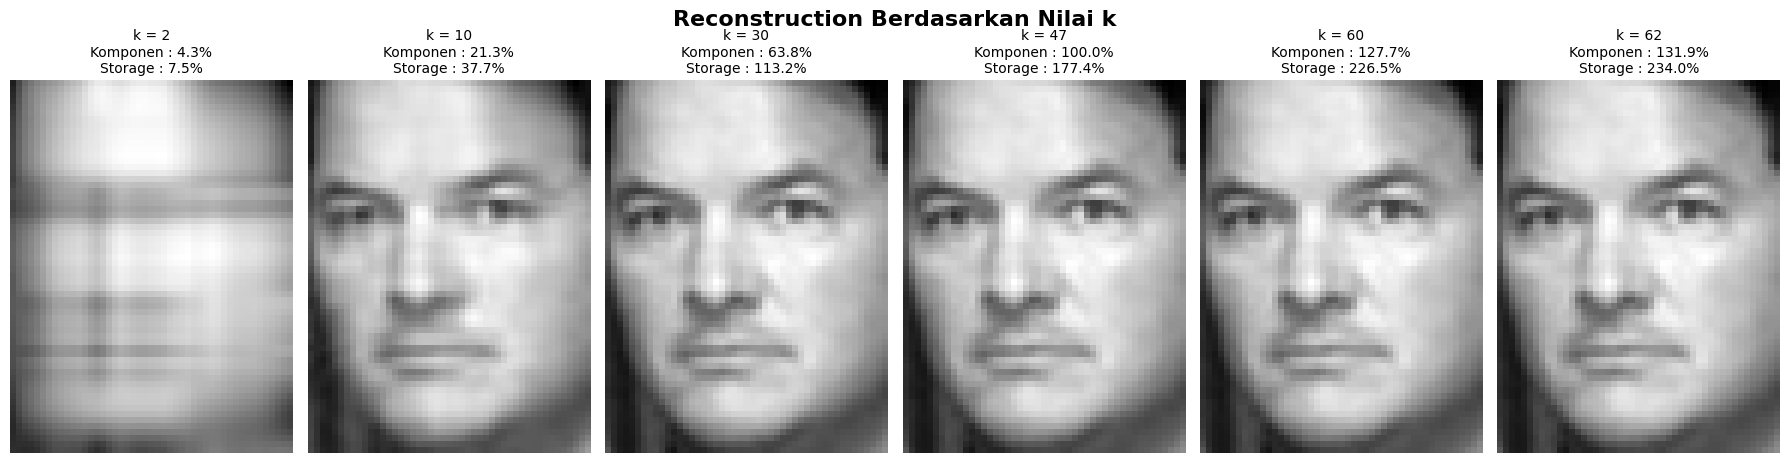


================ ANALISIS LAMBDA =================

================ LAMBDA =================
Lambda ke- 1 = 960.1624755859375
Lambda ke- 2 = 11.256271362304688
Lambda ke- 3 = 5.008810043334961
Lambda ke- 4 = 4.534659385681152
Lambda ke- 5 = 1.1335878372192383
Lambda ke- 6 = 0.8724526762962341
Lambda ke- 7 = 0.608807384967804
Lambda ke- 8 = 0.4219309389591217
Lambda ke- 9 = 0.2726961374282837
Lambda ke-10 = 0.19001208245754242
Lambda ke-11 = 0.12338901311159134
Lambda ke-12 = 0.08652569353580475
Lambda ke-13 = 0.07842952758073807
Lambda ke-14 = 0.06483956426382065
Lambda ke-15 = 0.04560881108045578
Lambda ke-16 = 0.030525246635079384
Lambda ke-17 = 0.0260513573884964
Lambda ke-18 = 0.02059139870107174
Lambda ke-19 = 0.013137317262589931
Lambda ke-20 = 0.012407355941832066
Lambda ke-21 = 0.0084999930113554
Lambda ke-22 = 0.00694891344755888
Lambda ke-23 = 0.005012337118387222
Lambda ke-24 = 0.003643645206466317
Lambda ke-25 = 0.0028828538488596678
Lambda ke-26 = 0.0022902379278093576
L

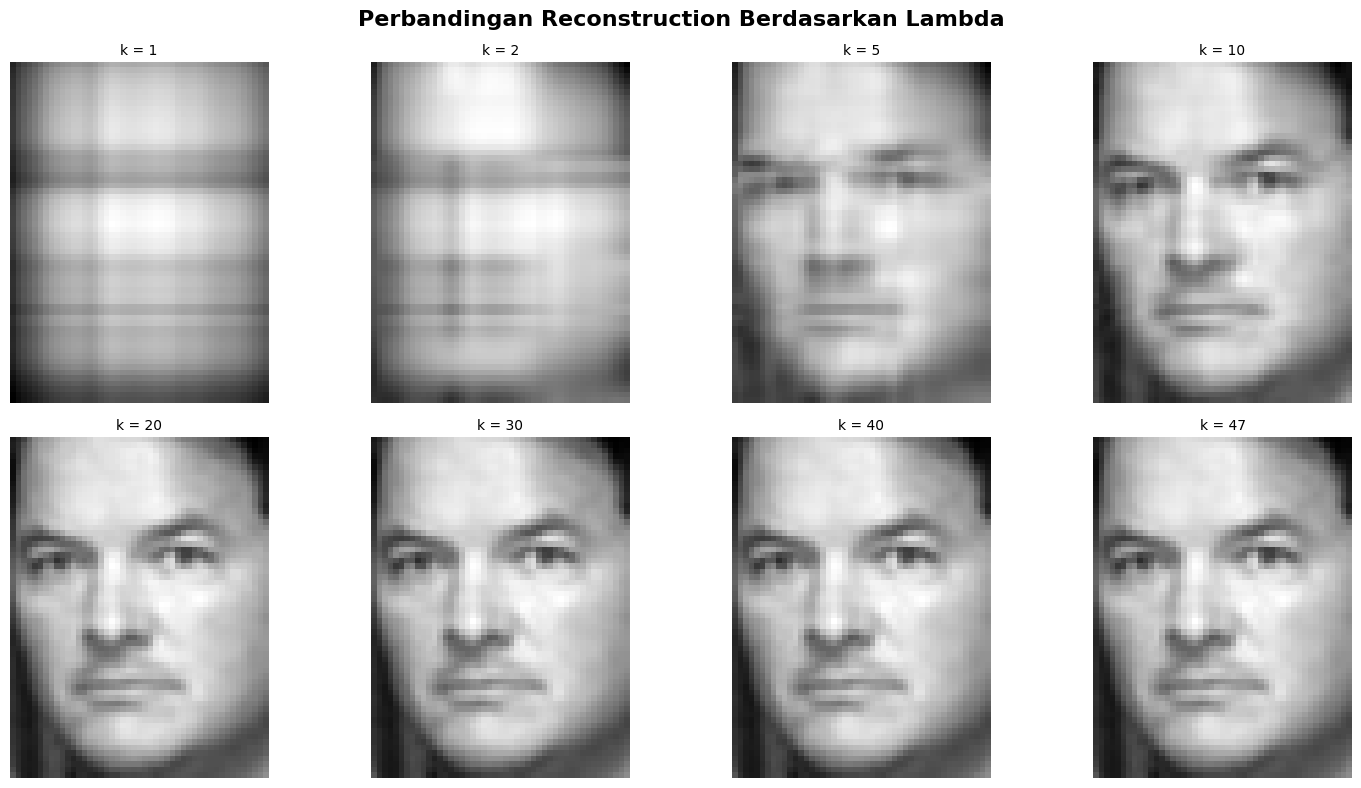


Analisis:

1. Lambda awal biasanya sangat besar
   -> menyimpan informasi wajah utama

2. Lambda akhir sangat kecil
   -> hanya menyimpan detail kecil/noise

3. Semakin banyak lambda digunakan:
   - wajah semakin mirip asli
   - error semakin kecil

4. Biasanya pada k sekitar 30 - 40,
   wajah sudah hampir identik
   dengan gambar asli.

5. Saat k = 47:
   - seluruh komponen utama digunakan
   - reconstruction hampir sempurna


================ PERBANDINGAN FINAL =================


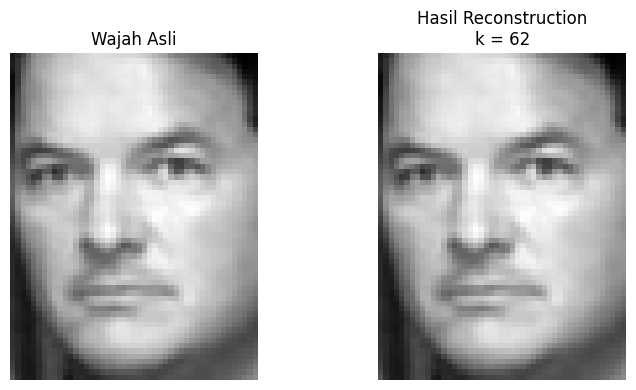

Nilai Mean Squared Error (MSE) : 1.1735237e-14

Analisis:
- k terbesar = 62
- Semakin besar k,
  hasil reconstruction semakin mirip
  dengan wajah asli.

- Jika k mendekati rank maksimum,
  maka hampir seluruh informasi gambar
  berhasil dipertahankan.

- Error reconstruction semakin kecil.


================ SINGULAR VALUES GRAPH =================


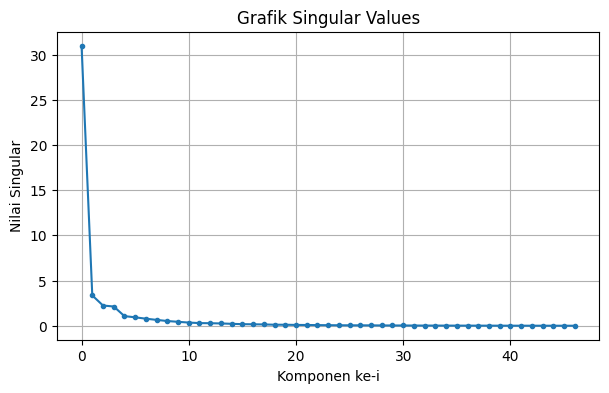


================ ANALISIS =================

1. Nilai singular awal sangat besar
   -> menyimpan informasi wajah utama

2. Nilai singular akhir sangat kecil
   -> hanya menyimpan detail kecil/noise

3. Semakin besar nilai k:
   - kualitas wajah semakin bagus
   - ukuran data semakin besar

4. Semakin kecil nilai k:
   - kompresi semakin tinggi
   - detail wajah mulai hilang

5. Konsep ini digunakan pada:
   - Eigenfaces
   - Face Recognition
   - Image Compression
   - PCA


================ SELESAI =================


In [ ]:
# =========================================================
# EIGENFACES + SVD STEP BY STEP
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# =========================================================
# LANGKAH 1 : LOAD DATASET WAJAH
# =========================================================
print("\n================ LOAD DATASET =================")

print("Mengambil dataset wajah LFW...")

lfw = fetch_lfw_people(resize=0.5)

print("Dataset berhasil dimuat!")

# dataset images
images = lfw.images

# label nama orang
labels = lfw.target

# nama class
target_names = lfw.target_names

print("\nJumlah gambar :", len(images))
print("Ukuran gambar :", images[0].shape)

# =========================================================
# LANGKAH 2 : AMBIL SATU CONTOH WAJAH
# =========================================================
print("\n================ CONTOH GAMBAR =================")

sample_index = 10

wajah_asli = images[sample_index]

h, w = wajah_asli.shape

print("Index gambar :", sample_index)
print("Dimensi gambar :", h, "x", w)

# tampilkan gambar asli
plt.figure(figsize=(4,4))

plt.imshow(wajah_asli, cmap='gray')

plt.title("Original Face")

plt.axis("off")

plt.show()

# =========================================================
# LANGKAH 3 : UBAH GAMBAR MENJADI VECTOR
# =========================================================
print("\n================ FLATTEN VECTOR =================")

sample_vector = wajah_asli.flatten()

print("Shape matrix asli :", wajah_asli.shape)

print("Shape vector :", sample_vector.shape)

print("\n5 nilai awal vector:")

print(sample_vector[:5])

# =========================================================
# LANGKAH 4 : PENJELASAN SVD
# =========================================================
print("\n================ PENJELASAN SVD =================")

print("""
A = U Σ VT

U     = basis fitur vertikal
Σ     = singular values / energi utama
VT    = basis fitur horizontal

SVD memecah gambar menjadi pola-pola utama.
Semakin besar singular value,
semakin penting fitur tersebut.
""")

# =========================================================
# LANGKAH 5 : PROSES SVD
# =========================================================
print("\n================ SVD PROCESS =================")

U, S, VT = np.linalg.svd(
    wajah_asli,
    full_matrices=False
)

SIGMA = np.diag(S)

# =========================================================
# DETAIL MATRIX
# =========================================================
print("\nUkuran Matriks:")

print("U     :", U.shape)
print("S     :", S.shape)
print("SIGMA :", SIGMA.shape)
print("VT    :", VT.shape)

print("\n5 Singular Values Pertama:")

print(S[:5])

# =========================================================
# VISUALISASI MATRIX U
# =========================================================
plt.figure(figsize=(5,5))

plt.imshow(U, cmap='gray')

plt.title("Matrix U")

plt.axis("off")

plt.show()

# =========================================================
# VISUALISASI MATRIX VT
# =========================================================
plt.figure(figsize=(5,5))

plt.imshow(VT, cmap='gray')

plt.title("Matrix VT")

plt.axis("off")

plt.show()

# =========================================================
# LANGKAH 6 : RECONSTRUCTION
# =========================================================
print("\n================ RECONSTRUCTION =================")

pilihan_k = [2, 10, 30, 47, 60, 62]

fig, axes = plt.subplots(
    1,
    len(pilihan_k),
    figsize=(18,5)
)

fig.suptitle(
    "Reconstruction Berdasarkan Nilai k",
    fontsize=16,
    fontweight='bold'
)

# =========================================================
# UKURAN ASLI GAMBAR
# =========================================================
original_size = h * w

# =========================================================
# LOOP RECONSTRUCTION
# =========================================================
for i, k in enumerate(pilihan_k):

    # =====================================================
    # POTONG MATRIX SVD
    # =====================================================
    U_k = U[:, :k]

    S_k = np.diag(S[:k])

    VT_k = VT[:k, :]

    # =====================================================
    # RECONSTRUCTION
    # =====================================================
    reconstructed = np.dot(
        U_k,
        np.dot(S_k, VT_k)
    )

    # =====================================================
    # PERSENTASE KOMPONEN
    # =====================================================
    rank_maksimum = min(h, w)

    persen_komponen = (
        k / rank_maksimum
    ) * 100

    # =====================================================
    # HITUNG STORAGE SVD
    # =====================================================
    ukuran_U = h * k

    ukuran_S = k

    ukuran_VT = k * w

    compressed_size = (
        ukuran_U +
        ukuran_S +
        ukuran_VT
    )

    storage_ratio = (
        compressed_size /
        original_size
    ) * 100

    # =====================================================
    # TAMPILKAN HASIL
    # =====================================================
    axes[i].imshow(
        reconstructed,
        cmap='gray'
    )

    axes[i].set_title(
        f"k = {k}"
        f"\nKomponen : {persen_komponen:.1f}%"
        f"\nStorage : {storage_ratio:.1f}%",
        fontsize=10
    )

    axes[i].axis("off")

plt.tight_layout()

plt.show()


# =========================================================
# ANALISIS LAMBDA (EIGENVALUE)
# =========================================================
print("\n================ ANALISIS LAMBDA =================")

# =========================================================
# HITUNG LAMBDA
# lambda = singular value^2
# =========================================================
lambda_values = S**2

print("\n================ LAMBDA =================")

for i in range(62):

    # jika masih dalam jumlah lambda asli
    if i < len(lambda_values):

        nilai_lambda = lambda_values[i]

    # sisanya isi 0
    else:

        nilai_lambda = 0

    print(
        f"Lambda ke-{i+1:2d} = {nilai_lambda}"
    )
# =========================================================
# CARI K YANG SUDAH MIRIP WAJAH ASLI
# =========================================================
print("\n================ PERBANDINGAN LAMBDA =================")

# beberapa k yang akan dibandingkan
k_values = [1, 2, 5, 10, 20, 30, 40, 47]

fig, axes = plt.subplots(
    2,
    len(k_values) // 2,
    figsize=(15,8)
)

axes = axes.ravel()

for i, k in enumerate(k_values):

    # =====================================================
    # RECONSTRUCTION
    # =====================================================
    U_k = U[:, :k]

    S_k = np.diag(S[:k])

    VT_k = VT[:k, :]

    reconstructed = np.dot(
        U_k,
        np.dot(S_k, VT_k)
    )

    # =====================================================
    # HITUNG ERROR
    # =====================================================
    mse = np.mean(
        (wajah_asli - reconstructed) ** 2
    )

    # =====================================================
    # SHOW IMAGE
    # =====================================================
    axes[i].imshow(
        reconstructed,
        cmap='gray'
    )

    axes[i].set_title(
        f"k = {k}",
        fontsize=10
    )

    axes[i].axis("off")

plt.suptitle(
    "Perbandingan Reconstruction Berdasarkan Lambda",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# =========================================================
# ANALISIS HASIL
# =========================================================
print("""
Analisis:

1. Lambda awal biasanya sangat besar
   -> menyimpan informasi wajah utama

2. Lambda akhir sangat kecil
   -> hanya menyimpan detail kecil/noise

3. Semakin banyak lambda digunakan:
   - wajah semakin mirip asli
   - error semakin kecil

4. Biasanya pada k sekitar 30 - 40,
   wajah sudah hampir identik
   dengan gambar asli.

5. Saat k = 47:
   - seluruh komponen utama digunakan
   - reconstruction hampir sempurna
""")
# =========================================================
# PERBANDINGAN WAJAH ASLI vs HASIL k TERBESAR
# Tambahkan di bawah bagian RECONSTRUCTION
# =========================================================
print("\n================ PERBANDINGAN FINAL =================")

# ambil k terbesar
k_terbesar = max(pilihan_k)

# =====================================================
# POTONG MATRIX
# =====================================================
U_k = U[:, :k_terbesar]

S_k = np.diag(S[:k_terbesar])

VT_k = VT[:k_terbesar, :]

# =====================================================
# RECONSTRUCTION FINAL
# =====================================================
reconstructed_final = np.dot(
    U_k,
    np.dot(S_k, VT_k)
)

# =====================================================
# TAMPILKAN PERBANDINGAN
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# gambar asli
axes[0].imshow(wajah_asli, cmap='gray')
axes[0].set_title("Wajah Asli")
axes[0].axis("off")

# hasil reconstruction
axes[1].imshow(reconstructed_final, cmap='gray')
axes[1].set_title(f"Hasil Reconstruction\nk = {k_terbesar}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# HITUNG ERROR
# =====================================================
error = np.mean(
    (wajah_asli - reconstructed_final) ** 2
)

print("Nilai Mean Squared Error (MSE) :", error)

# =====================================================
# ANALISIS
# =====================================================
print(f"""
Analisis:
- k terbesar = {k_terbesar}
- Semakin besar k,
  hasil reconstruction semakin mirip
  dengan wajah asli.

- Jika k mendekati rank maksimum,
  maka hampir seluruh informasi gambar
  berhasil dipertahankan.

- Error reconstruction semakin kecil.
""")

# =========================================================
# LANGKAH 7 : GRAFIK SINGULAR VALUES
# =========================================================
print("\n================ SINGULAR VALUES GRAPH =================")

plt.figure(figsize=(7,4))

plt.plot(
    S,
    marker='o',
    markersize=3,
    linestyle='-'
)

plt.title(
    "Grafik Singular Values"
)

plt.xlabel(
    "Komponen ke-i"
)

plt.ylabel(
    "Nilai Singular"
)

plt.grid(True)

plt.show()

# =========================================================
# LANGKAH 8 : PENJELASAN HASIL
# =========================================================
print("\n================ ANALISIS =================")

print("""
1. Nilai singular awal sangat besar
   -> menyimpan informasi wajah utama

2. Nilai singular akhir sangat kecil
   -> hanya menyimpan detail kecil/noise

3. Semakin besar nilai k:
   - kualitas wajah semakin bagus
   - ukuran data semakin besar

4. Semakin kecil nilai k:
   - kompresi semakin tinggi
   - detail wajah mulai hilang

5. Konsep ini digunakan pada:
   - Eigenfaces
   - Face Recognition
   - Image Compression
   - PCA
""")

print("\n================ SELESAI =================")

# Penjelasan Eigenfaces

## Pengertian Eigenfaces

Eigenfaces adalah metode pengenalan wajah (*face recognition*) yang menggunakan konsep:

* Aljabar Linear
* Eigenvector
* Eigenvalue
* PCA (*Principal Component Analysis*)
* SVD (*Singular Value Decomposition*)

Tujuan utama Eigenfaces adalah:

* mengenali wajah,
* mengurangi dimensi data gambar,
* dan mengambil fitur penting dari wajah.

Metode ini mengubah gambar wajah menjadi sekumpulan angka matematika yang merepresentasikan ciri khas wajah.

---

# Konsep Dasar Eigenfaces

Setiap gambar wajah sebenarnya adalah matriks piksel.

Contoh:

```text
Gambar 50x50
=
2500 nilai piksel
```

Artinya:

* setiap gambar memiliki ribuan fitur,
* sehingga proses pengenalan wajah menjadi berat.

Eigenfaces menyelesaikan masalah ini dengan:

* mengambil fitur paling penting,
* membuang informasi yang kurang penting,
* menyimpan wajah dalam dimensi lebih kecil.

---

# Ide Utama Eigenfaces

Eigenfaces mencari:

> “Pola wajah utama yang paling sering muncul.”

Misalnya:

* bentuk mata,
* posisi hidung,
* kontur wajah,
* bayangan wajah.

Pola-pola tersebut disebut:

```text
Eigenfaces
```

Eigenfaces bukan wajah manusia normal,
tetapi pola matematis hasil kombinasi banyak wajah.

---

# Alur Kerja Eigenfaces

## 1. Load Dataset Wajah

Program membaca banyak gambar wajah.

Contoh:

```text
Faces/
├── person1/
├── person2/
├── person3/
```

Setiap gambar:

* diubah grayscale,
* diresize,
* lalu diubah menjadi vector.

---

## 2. Mengubah Gambar Menjadi Vector

Gambar:

```text
50 x 50
```

diubah menjadi:

```text
2500 x 1
```

menggunakan:

```python
flatten()
```

Tujuannya agar bisa dihitung menggunakan operasi matriks.

---

## 3. Mean Face

Semua wajah dirata-ratakan:

```text
mean_face = rata-rata seluruh wajah
```

Hasilnya disebut:

```text
Mean Face
```

Mean face adalah wajah rata-rata dari seluruh dataset.

---

## 4. Centering

Setiap wajah dikurangi mean face:

```text
A = X - mean_face
```

Tujuannya:

* menghilangkan informasi umum,
* menyisakan perbedaan unik antar wajah.

---

# SVD pada Eigenfaces

Setelah mendapatkan matrix A,
dilakukan:

```text
A = U Σ VT
```

Menggunakan:

```python
np.linalg.svd()
```

---

# Penjelasan Matriks SVD

## 1. Matrix U

Berisi:

* pola fitur vertikal,
* kombinasi basis data.

Ukuran:

```text
jumlah_gambar x jumlah_gambar
```

---

## 2. Singular Values (Σ)

Berisi:

* tingkat kepentingan fitur,
* energi informasi.

Nilai terbesar:

* fitur paling penting.

Nilai kecil:

* noise atau detail kecil.

---

## 3. Matrix VT

Berisi:

* fitur utama wajah,
* arah variasi wajah.

Baris-baris pertama VT disebut:

```text
Eigenfaces
```

---

# Eigenfaces

Eigenfaces adalah:

```text
eigenfaces = VT[:K]
```

K = jumlah fitur utama yang dipilih.

Misalnya:

```python
K = 20
```

artinya hanya 20 fitur wajah terpenting yang digunakan.

---

# Projection

Wajah diproyeksikan ke ruang eigenfaces:

```text
projected_face = A × eigenfacesᵀ
```

Hasilnya:

* wajah berubah menjadi vector fitur,
* ukurannya jauh lebih kecil.

---

# Recognition / Matching

Untuk mengenali wajah:

1. wajah test diproyeksikan,
2. dibandingkan dengan seluruh wajah training,
3. dihitung jaraknya.

Biasanya menggunakan:

```python
np.linalg.norm()
```

Wajah dengan jarak terkecil dianggap paling mirip.

---

# Reconstruction

Eigenfaces juga bisa membangun ulang wajah:

```text
reconstructed =
mean_face + projection × eigenfaces
```

Jika nilai K besar:

* wajah semakin jelas.

Jika K kecil:

* wajah blur tetapi ukuran data kecil.

---

# Hubungan Eigenfaces dan PCA

Eigenfaces sebenarnya adalah implementasi PCA untuk gambar wajah.

PCA digunakan untuk:

* mencari dimensi terpenting,
* mengurangi data,
* mempertahankan informasi utama.

---

# Kelebihan Eigenfaces

## 1. Cepat

Karena dimensi data diperkecil.

---

## 2. Hemat Memori

Tidak perlu menyimpan semua piksel penuh.

---

## 3. Mudah Diimplementasikan

Bisa menggunakan:

* NumPy
* SVD
* PCA

---

# Kekurangan Eigenfaces

## 1. Sensitif Cahaya

Perbedaan pencahayaan dapat mempengaruhi hasil.

---

## 2. Sensitif Pose

Jika posisi kepala berubah:

* akurasi turun.

---

## 3. Kurang Bagus untuk Dataset Besar

Metode modern seperti:

* CNN,
* Deep Learning,
* FaceNet,
  lebih akurat.

---

# Penerapan Eigenfaces

Eigenfaces digunakan pada:

* Face Recognition
* Sistem Absensi
* Keamanan
* Image Compression
* Computer Vision
* PCA Learning
* Pattern Recognition

---

# Kesimpulan

Eigenfaces bekerja dengan cara:

1. mengubah wajah menjadi matriks,
2. mencari fitur utama menggunakan SVD/PCA,
3. membentuk eigenfaces,
4. memproyeksikan wajah ke ruang fitur,
5. membandingkan kemiripan wajah menggunakan jarak.

Konsep utamanya adalah:

```text
Mengubah gambar wajah besar
menjadi representasi fitur kecil
tanpa kehilangan informasi penting.
```
